In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv("cardekho.csv")

In [3]:
df.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [4]:
df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110,5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.30,1248.0,73.9,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70,5.0
8127,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70,5.0


In [5]:
df.shape

(8128, 12)

In [6]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1202)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.shape

(6926, 12)

In [10]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    208
engine                208
max_power             205
seats                 208
dtype: int64

In [11]:
df["mileage(km/ltr/kg)"].fillna(df["mileage(km/ltr/kg)"].mode()[0], inplace=True)

df["engine"].fillna(df["engine"].mode()[0], inplace=True)

df["max_power"].fillna(df["max_power"].mode()[0], inplace=True)

df["seats"].fillna(df["seats"].mode()[0], inplace=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_3616\3817939136.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["mileage(km/ltr/kg)"].fillna(df["mileage(km/ltr/kg)"].mode()[0], inplace=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_3616\3817939136.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or 

0       5.0
1       5.0
2       5.0
3       5.0
4       5.0
       ... 
8121    5.0
8122    5.0
8123    5.0
8124    5.0
8125    5.0
Name: seats, Length: 6926, dtype: float64

In [13]:
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    208
engine                208
max_power             205
seats                 208
dtype: int64

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                6926 non-null   str    
 1   year                6926 non-null   int64  
 2   selling_price       6926 non-null   int64  
 3   km_driven           6926 non-null   int64  
 4   fuel                6926 non-null   str    
 5   seller_type         6926 non-null   str    
 6   transmission        6926 non-null   str    
 7   owner               6926 non-null   str    
 8   mileage(km/ltr/kg)  6718 non-null   float64
 9   engine              6718 non-null   float64
 10  max_power           6721 non-null   str    
 11  seats               6718 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 1.1 MB


In [15]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [16]:
df["max_power"] = pd.to_numeric(df["max_power"], errors="coerce")

In [17]:
df["mileage(km/ltr/kg)"] = df["mileage(km/ltr/kg)"].fillna(df["mileage(km/ltr/kg)"].mode()[0])

df["engine"] = df["engine"].fillna(df["engine"].mode()[0])

df["max_power"] = df["max_power"].fillna(df["max_power"].mode()[0])

df["seats"] = df["seats"].fillna(df["seats"].mode()[0])

In [18]:
df.isnull().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

In [19]:
df["fuel"].unique()

<ArrowStringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str

In [20]:
df["seller_type"].unique()

<ArrowStringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

In [21]:
df["transmission"].unique()

<ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

In [22]:
df["owner"].unique()

<ArrowStringArray>
[         'First Owner',         'Second Owner',          'Third Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str

In [23]:
df["name"].nunique()

2058

In [24]:
df.drop("name", axis=1, inplace=True)

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["fuel"] = le.fit_transform(df["fuel"])
df["seller_type"] = le.fit_transform(df["seller_type"])
df["transmission"] = le.fit_transform(df["transmission"])
df["owner"] = le.fit_transform(df["owner"])

In [26]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,2014,450000,145500,1,1,1,0,23.40,1248.0,74.00,5.0
1,2014,370000,120000,1,1,1,2,21.14,1498.0,103.52,5.0
2,2006,158000,140000,3,1,1,4,17.70,1497.0,78.00,5.0
3,2010,225000,127000,1,1,1,0,23.00,1396.0,90.00,5.0
4,2007,130000,120000,3,1,1,0,16.10,1298.0,88.20,5.0


In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                6926 non-null   int64  
 1   selling_price       6926 non-null   int64  
 2   km_driven           6926 non-null   int64  
 3   fuel                6926 non-null   int64  
 4   seller_type         6926 non-null   int64  
 5   transmission        6926 non-null   int64  
 6   owner               6926 non-null   int64  
 7   mileage(km/ltr/kg)  6926 non-null   float64
 8   engine              6926 non-null   float64
 9   max_power           6926 non-null   float64
 10  seats               6926 non-null   float64
dtypes: float64(4), int64(7)
memory usage: 649.3 KB


In [28]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 30824.52, -1.01,-38623.28,..., 69.08, 8575.28, -7796.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['year','km_driven','fuel',...,'engine','max_power','seats']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-6.184e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [31]:
y_pred = lr.predict(X_test)

In [32]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score :", r2_score(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))

R2 Score : 0.5679548322134405
MSE : 94756849564.75667


In [33]:
print(lr.coef_)
print(lr.intercept_)

[ 3.08245229e+04 -1.01104823e+00 -3.86232765e+04 -1.30041272e+05
 -3.27458170e+05 -1.19197950e+04  3.39095566e+03  6.90824920e+01
  8.57527863e+03 -7.79643428e+03]
-61838501.81836509


In [34]:
sample = X.iloc[[0]]

print(sample)

lr.predict(sample)

   year  km_driven  fuel  seller_type  transmission  owner  \
0  2014     145500     1            1             1      0   

   mileage(km/ltr/kg)  engine  max_power  seats  
0                23.4  1248.0       74.0    5.0  


array([360008.76323409])

In [35]:
X.columns

Index(['year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner',
       'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats'],
      dtype='str')

In [36]:
import pickle

pickle.dump(lr, open("Car_Price_Prediction.pkl", "wb"))

In [37]:
model = pickle.load(open("Car_Price_Prediction.pkl", "rb"))

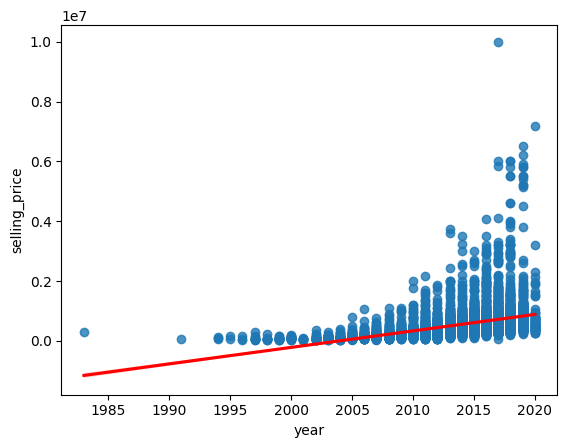

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    x="year",
    y="selling_price",
    data=df,
    line_kws={"color":"red"}
)

plt.show()